# Regresion y regularizacion 

Pamela Cerdas Matamoros 

In [45]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
# Importar Librerias 
import numpy as np
import matplotlib.pyplot as pyplot
import random
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

## Parte 1: Regularizacion mediante un ejemplo polinomial 

In [47]:
x1 = np.arange(-1.3, 3.5, 0.125)

In [48]:
x2 = x1 = x1
x3 = x1 = x1 = x1

In [49]:
w = np.concatenate((np.vstack(x1), np.vstack(x2), np.vstack(x3)), axis=1)

In [50]:
X = pd.DataFrame(w, columns=['x1', 'x2', 'x3'])

In [51]:
# coeficiente de la funcion
w0 = 190
w1 = -85/3
w2 = -165
w3 = 160/3

In [52]:
# Introducir ruido a la funcion 
noise = 200 *(random.random() - 0.5)

In [53]:
X.head()

,x1,x2,x3
0,-1.300,-1.300,-1.300
1,-1.175,-1.175,-1.175
2,-1.050,-1.050,-1.050
3,-0.925,-0.925,-0.925
4,-0.800,-0.800,-0.800


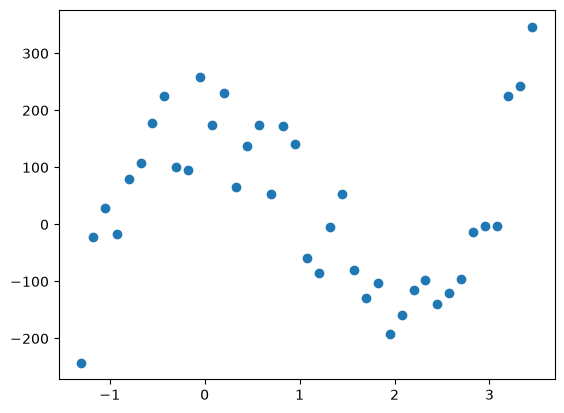

In [54]:
# Definimos nuestra variable de salida con algo de ruido para que nuestro problema
# no se reduzca simplemente a un problema de interpolación de puntos:

random.seed(1)
yreal = []
for x in x1:
  noise=200*(random.random() -0.5)
  cc = w3*np.power(x,3) + w2*np.power(x,2) + w1*x + w0 + noise
  yreal.append(cc)
  
  
plt.scatter(x1,yreal)
plt.show()

In [55]:
# Definamos 4 modelos: el de regresión lineal múltiple (RLM); de RLM con 
# regularización L1 (lasso); de RLM con regularización L2 (ridge) y
# RLM con regularización conjunta L1 y L2 (elastic-net):  

modelos = []
modelos.append(('LR', LinearRegression()))
modelos.append(('LASSO', Lasso(alpha=30)))  
modelos.append(('RIDGE', Ridge(alpha=30)))  
modelos.append(('EN', ElasticNet(alpha=1, l1_ratio=.5)))

In [56]:
yhat0 = []   # predicciones del modelo RLM
yhat1 = []   # predicciones del RLM con regularización L1
yhat2 = []   # predicciones del RLM con regularización L2
yhat12 = []  # predicciones del RLM con regularización L1 y L2

In [57]:
for name, model in modelos:
  # entrenamos el modelo seleccionado y obtenemos sus predicciones:
  print("%s:" % name)
  mm = model.fit(X, np.ravel(yreal))
  yhat = mm.predict(X)
  
  print(mm.intercept_)   # por si deseas conocer w0.
  print(mm.coef_)       # despleguemos los pesos obtenidos

  if name=='LR':
    yhat0.append(yhat)
    print('\n')
  elif name=='LASSO':
    yhat1.append(yhat)
    print('\n')
  elif name=='RIDGE':
    yhat2.append(yhat)
    print('\n')
  else:
    yhat12.append(yhat)

LR:
51.1450237412943
[-4.62597253 -4.62597253 -4.62597253]


LASSO:
36.226262323717975
[0. 0. 0.]


RIDGE:
49.433911320640405
[-4.09539504 -4.09539504 -4.09539504]


EN:
49.73563969457352
[-4.18913784 -4.18813241 -4.18959242]


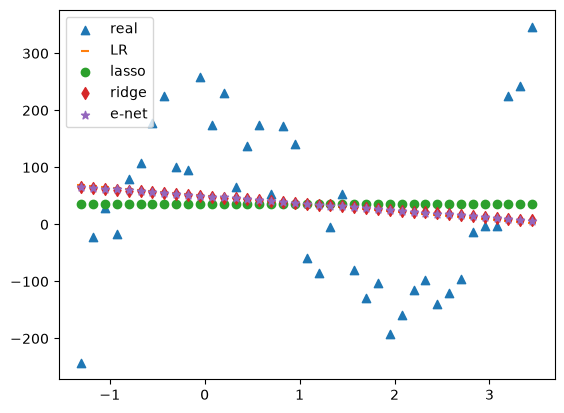

In [58]:
plt.scatter(x1, np.ravel(yreal), marker='^', label='real')  

plt.scatter(x1, np.ravel(yhat0), marker='_', label='LR')  
plt.scatter(x1, np.ravel(yhat1), marker='o', label='lasso')  
plt.scatter(x1, np.ravel(yhat2), marker='d', label='ridge')  
plt.scatter(x1, np.ravel(yhat12), marker='*', label='e-net')

plt.legend(loc=2)
plt.show()

## Fine Tuning (Ajuste Final)

 Busqueda por malla / Grid search 

In [59]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

In [60]:
# RIDGE - métrica L2:

modelo = LogisticRegression(penalty='l2', max_iter=10000, random_state=1)

dicc_grid = {'C':[0.0001,0.01,0.1,1.0,10.,100.],
             'solver':['newton-cg','lbfgs','liblinear','sag','saga']
             }

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=8)

grid = GridSearchCV(estimator=modelo, 
                    param_grid=dicc_grid, 
                    cv=cv, 
                    scoring='accuracy')

NameError: name 'LogisticRegression' is not defined

In [61]:
# Transformamos los datos de entrada:
Xx = columnasTransformer.fit_transform(Xtv)

# Llevamos a cabo el proceso de etrenamiento con validación-cruzada y búsqueda de malla.
# Observa que de acuerdo a las opciones incluidas en la malla, se estarán realizando (6)(5)=30 
# combinaciones diferentes, además de las (10)(5)=50 particiones de la validación-cruzada,
# lo cual implica también un mayor tiempo de entrenamiento.

grid.fit(Xx, np.ravel(ytv))

print('Mejor valor de exactitud obtenido con la mejor combinación:', grid.best_score_)
print('Mejor combinación de valores encontrados de los hiperparámetros:', grid.best_params_)
print('Métrica utilizada:', grid.scoring)

NameError: name 'columnasTransformer' is not defined

## Modelo final con el conjunto de pruebas 

In [62]:
modelo = LogisticRegression(penalty='l2', 
                            max_iter=10000,
                            C=100.0,
                            solver='liblinear',
                            random_state=1)

# Entrenamos el modelo por última vez con los datos de entrenamiento y validación conjuntos:
Xct = columnasTransformer.fit(Xtv)
Xxt = Xct.transform(Xtv)
modelo.fit(Xxt, np.ravel(ytv))

# Transformamos los datos de prueba y los utilizamos por primera vez para obtener sus predicciones
# y desempeño del modelo:

Xxtest = Xct.transform(Xtest)
print(modelo.score(Xxtest, np.ravel(ytest)))

NameError: name 'LogisticRegression' is not defined

In [63]:
txt = ['Verdaderos Negativos','Falsos Positivos','Falsos Negativos','Verdaderos Positivos']
frecuencia = ["{0:0.0f}".format(value) for value in cm.flatten()]
porcentaje = ["{0:.1%}".format(value) for value in cm.flatten()/np.sum(cm)]

labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(txt,frecuencia,porcentaje)]
labels = np.asarray(labels).reshape(2,2)

ax = sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False)
ax.set(ylabel="Etiquetas Reales", xlabel="Etiquetas de Predicción")
plt.show()

NameError: name 'cm' is not defined